In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [4]:
# --- 1. Load Data ---
# Define file paths
elephants_file = 'comparative_results_1.csv'
graffiti_file = 'comparative_results_2.csv'
city_file = 'comparative_results_3.csv'

# Check for file existence and load
data_frames = []
try:
    data_city = pd.read_csv(city_file)
    data_city['experiment'] = 'City (Building)'
    data_frames.append(data_city)
except FileNotFoundError:
    print(f"Warning: File not found - {city_file}")

try:
    data_elephants = pd.read_csv(elephants_file)
    data_elephants['experiment'] = 'Wildlife (Elephants)'
    data_frames.append(data_elephants)
except FileNotFoundError:
    print(f"Warning: File not found - {elephants_file}")

try:
    data_graffiti = pd.read_csv(graffiti_file)
    data_graffiti['experiment'] = 'Urban (Graffiti)'
    data_frames.append(data_graffiti)
except FileNotFoundError:
    print(f"Warning: File not found - {graffiti_file}")

if not data_frames:
    print("Error: No CSV files were found. Cannot proceed with analysis.")
else:
    # Concatenate all data into one DataFrame
    all_data = pd.concat(data_frames, ignore_index=True)
    print("Successfully loaded and combined data from all 3 experiments.")

Successfully loaded and combined data from all 3 experiments.


In [5]:
# --- 2. Create Summary Table ---
metrics_to_average = ['final_confidence', 'word_count', 'processing_time']
# Group by blur_radius, system_type, AND experiment
summary_table = all_data.groupby(['blur_radius', 'system_type', 'experiment'])[metrics_to_average].mean().reset_index()

print("--- Aggregated Summary Table (All Experiments) ---")
print(summary_table.to_string())

--- Aggregated Summary Table (All Experiments) ---
    blur_radius system_type            experiment  final_confidence  word_count  processing_time
0           0.0         MAS       City (Building)               9.0        34.5       157.709211
1           0.0         MAS      Urban (Graffiti)               9.0        41.0       110.333958
2           0.0         MAS  Wildlife (Elephants)               9.0        55.5        98.835866
3           0.0         SAS       City (Building)               8.5        21.5        13.529277
4           0.0         SAS      Urban (Graffiti)               6.5        16.5        10.205182
5           0.0         SAS  Wildlife (Elephants)              10.0        18.5         7.650574
6           2.0         MAS       City (Building)               9.0        32.0       412.142692
7           2.0         MAS      Urban (Graffiti)               9.0        36.5       212.977334
8           2.0         MAS  Wildlife (Elephants)               9.0        5

In [7]:
# --- 3. Plotting Setup (NEW STYLE) ---
plt.style.use('ggplot')

# Use COLOR for SAS vs MAS
colors = {'SAS': '#D55E00', 'MAS': '#0072B2'} # Red/Orange and Blue

# Use LINESTYLE to differentiate experiments
linestyles = {'City (Building)': 'solid', 'Wildlife (Elephants)': 'dashed', 'Urban (Graffiti)': 'dotted'}

# Use MARKERS to also differentiate SAS vs MAS
markers = {'SAS': 'o', 'MAS': 's'}

Saved chart_1_aggregated_confidence_v2.png


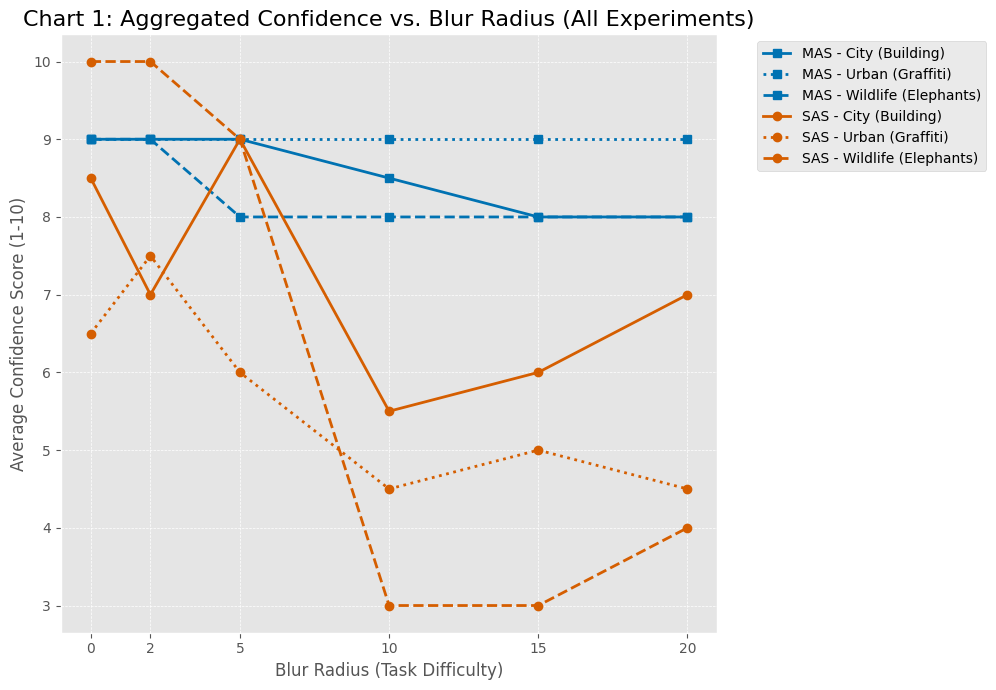

In [8]:
# --- 4. Generate Chart 1: Confidence vs. Blur Radius ---
plt.figure(figsize=(12, 7))
for (system, experiment), group in summary_table.groupby(['system_type', 'experiment']):
    label = f'{system} - {experiment}'
    plt.plot(group['blur_radius'], group['final_confidence'], label=label, 
             marker=markers[system], 
             linestyle=linestyles[experiment], 
             color=colors[system], 
             linewidth=2)

plt.title('Chart 1: Aggregated Confidence vs. Blur Radius (All Experiments)', fontsize=16)
plt.xlabel('Blur Radius (Task Difficulty)', fontsize=12)
plt.ylabel('Average Confidence Score (1-10)', fontsize=12)
plt.xticks(summary_table['blur_radius'].unique())
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
plt.savefig('chart_1_aggregated_confidence_v2.png')
print("Saved chart_1_aggregated_confidence_v2.png")
plt.show()

Saved chart_2_aggregated_time_v2.png


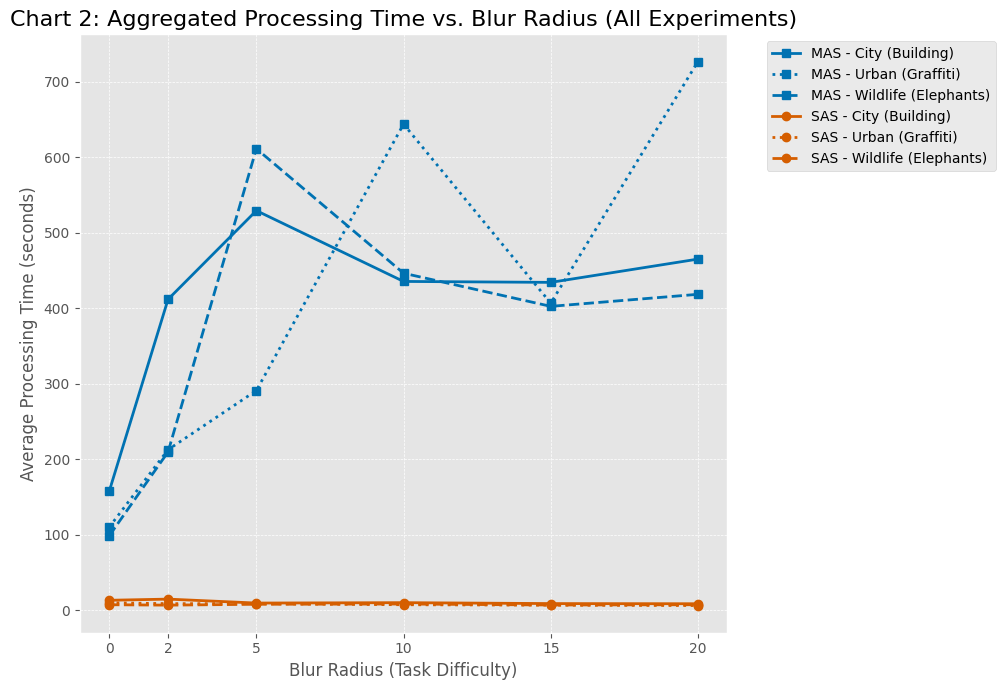

In [9]:
# --- 5. Generate Chart 2: Processing Time vs. Blur Radius ---
plt.figure(figsize=(12, 7))
for (system, experiment), group in summary_table.groupby(['system_type', 'experiment']):
    label = f'{system} - {experiment}'
    plt.plot(group['blur_radius'], group['processing_time'], label=label, 
             marker=markers[system], 
             linestyle=linestyles[experiment], 
             color=colors[system], 
             linewidth=2)

plt.title('Chart 2: Aggregated Processing Time vs. Blur Radius (All Experiments)', fontsize=16)
plt.xlabel('Blur Radius (Task Difficulty)', fontsize=12)
plt.ylabel('Average Processing Time (seconds)', fontsize=12)
plt.xticks(summary_table['blur_radius'].unique())
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('chart_2_aggregated_time_v2.png')
print("Saved chart_2_aggregated_time_v2.png")
plt.show()

Saved chart_3_aggregated_wordcount_v2.png


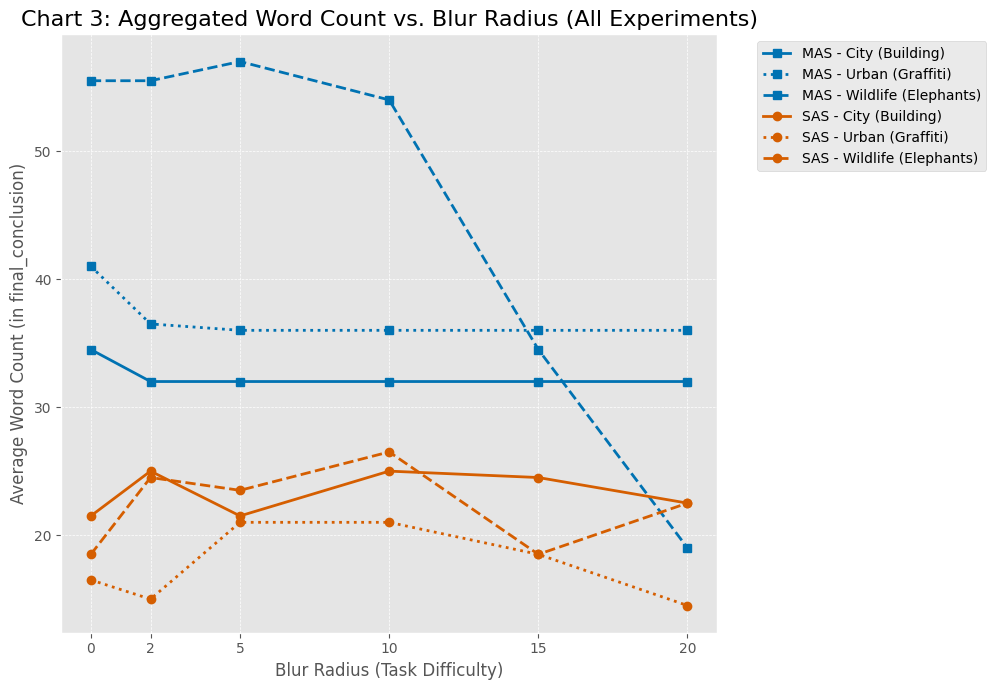

In [10]:
# --- 6. Generate Chart 3: Word Count vs. Blur Radius ---
plt.figure(figsize=(12, 7))
for (system, experiment), group in summary_table.groupby(['system_type', 'experiment']):
    label = f'{system} - {experiment}'
    plt.plot(group['blur_radius'], group['word_count'], label=label, 
             marker=markers[system], 
             linestyle=linestyles[experiment], 
             color=colors[system], 
             linewidth=2)

plt.title('Chart 3: Aggregated Word Count vs. Blur Radius (All Experiments)', fontsize=16)
plt.xlabel('Blur Radius (Task Difficulty)', fontsize=12)
plt.ylabel('Average Word Count (in final_conclusion)', fontsize=12)
plt.xticks(summary_table['blur_radius'].unique())
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('chart_3_aggregated_wordcount_v2.png')
print("Saved chart_3_aggregated_wordcount_v2.png")
plt.show()